# Biological Data Visualization: Seaborn & Matplotlib

### Step 1: Understanding the Dataset

In [2]:
import urllib.request

url = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/"
    "GSE65nnn/GSE65194/matrix/"
    "GSE65194_series_matrix.txt.gz"
)

filename = "GSE65194_series_matrix.txt.gz"

urllib.request.urlretrieve(url, filename)

print("Download completed.")

Download completed.


In [1]:
import pandas as pd

matrix_file = "../data/raw/GSE65194_series_matrix.txt.gz"

df = pd.read_csv(
    matrix_file,
    sep="\t",
    comment="!",
    index_col=0
)

df.head()

,GSM1588970,GSM1588971,GSM1588972,GSM1588973,GSM1588974,GSM1588975,GSM1588976,GSM1588977,GSM1588978,GSM1588979,...,GSM1589144,GSM1589145,GSM1589146,GSM1589147,GSM1589148,GSM1589149,GSM1589150,GSM1589151,GSM1589152,GSM1589153
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,10.411779,10.488352,10.845107,10.702966,9.098584,9.829192,9.470653,9.664682,9.684121,9.763926,...,9.804565,9.969140,11.184470,6.374995,8.928622,9.784214,9.563211,8.517468,8.451605,8.843594
1053_at,6.591003,6.746441,7.785105,7.680055,8.492950,8.043909,8.363112,8.740721,8.703165,9.211186,...,6.544417,5.457921,9.024600,9.044131,4.979578,9.551200,5.956611,5.626144,8.426716,9.078589
117_at,5.903459,5.964176,7.073847,6.238866,7.898332,6.251101,5.954255,7.188710,6.861743,6.205198,...,3.370990,3.143524,3.144014,3.759428,3.405318,4.397315,4.524447,4.930555,3.260828,3.845806
121_at,2.708618,2.289952,2.391005,2.803893,2.794781,2.782041,2.806578,3.108409,3.836726,3.923927,...,2.708220,2.701309,2.596828,5.574557,2.860321,2.871901,2.733621,2.737100,2.628306,5.842461
1255_g_at,2.058521,2.055400,2.055344,2.080104,2.052719,2.065556,2.057589,2.069383,2.047526,2.062470,...,2.080661,2.069928,2.102840,2.116986,2.128656,2.105839,2.067705,2.080564,2.099971,2.076347


In [2]:
print(df.shape)

(54673, 178)


54,673 probes
×
164 samples

In [3]:
df.head()

,GSM1588970,GSM1588971,GSM1588972,GSM1588973,GSM1588974,GSM1588975,GSM1588976,GSM1588977,GSM1588978,GSM1588979,...,GSM1589144,GSM1589145,GSM1589146,GSM1589147,GSM1589148,GSM1589149,GSM1589150,GSM1589151,GSM1589152,GSM1589153
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,10.411779,10.488352,10.845107,10.702966,9.098584,9.829192,9.470653,9.664682,9.684121,9.763926,...,9.804565,9.969140,11.184470,6.374995,8.928622,9.784214,9.563211,8.517468,8.451605,8.843594
1053_at,6.591003,6.746441,7.785105,7.680055,8.492950,8.043909,8.363112,8.740721,8.703165,9.211186,...,6.544417,5.457921,9.024600,9.044131,4.979578,9.551200,5.956611,5.626144,8.426716,9.078589
117_at,5.903459,5.964176,7.073847,6.238866,7.898332,6.251101,5.954255,7.188710,6.861743,6.205198,...,3.370990,3.143524,3.144014,3.759428,3.405318,4.397315,4.524447,4.930555,3.260828,3.845806
121_at,2.708618,2.289952,2.391005,2.803893,2.794781,2.782041,2.806578,3.108409,3.836726,3.923927,...,2.708220,2.701309,2.596828,5.574557,2.860321,2.871901,2.733621,2.737100,2.628306,5.842461
1255_g_at,2.058521,2.055400,2.055344,2.080104,2.052719,2.065556,2.057589,2.069383,2.047526,2.062470,...,2.080661,2.069928,2.102840,2.116986,2.128656,2.105839,2.067705,2.080564,2.099971,2.076347


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 54673 entries, 1007_s_at to AFFX-TrpnX-M_at
Columns: 178 entries, GSM1588970 to GSM1589153
dtypes: float64(178)
memory usage: 74.7+ MB


In [5]:
sample_ids = df.columns.tolist()

print(f"Number of samples: {len(sample_ids)}")
print("First 10 samples:")
print(sample_ids[:10])

Number of samples: 178
First 10 samples:
['GSM1588970', 'GSM1588971', 'GSM1588972', 'GSM1588973', 'GSM1588974', 'GSM1588975', 'GSM1588976', 'GSM1588977', 'GSM1588978', 'GSM1588979']


In [6]:
print("Number of probes:", df.shape[0])
print("Number of samples:", df.shape[1])

Number of probes: 54673
Number of samples: 178


In [8]:
df.index[:10]

Index(['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at',
       '1316_at', '1320_at', '1405_i_at', '1431_at'],
      dtype='str', name='ID_REF')

In [9]:
df.columns[-10:]

Index(['GSM1589144', 'GSM1589145', 'GSM1589146', 'GSM1589147', 'GSM1589148',
       'GSM1589149', 'GSM1589150', 'GSM1589151', 'GSM1589152', 'GSM1589153'],
      dtype='str')

- Read Metadata

In [10]:
import gzip

metadata_lines = []

with gzip.open(
    matrix_file,
    "rt",
    encoding="utf-8"
) as f:

    for line in f:
        if line.startswith("!Sample_"):
            metadata_lines.append(line.strip())

print(f"Number of metadata lines: {len(metadata_lines)}")

Number of metadata lines: 36


In [11]:
for line in metadata_lines:
    print(line[:500])

!Sample_title	"TNBC, TUM001_repA"	"TNBC, TUM001_repB"	"Her2, TUM002_repA"	"Her2, TUM002_repB"	"TNBC, TUM003"	"TNBC, TUM004"	"TNBC, TUM005"	"TNBC, TUM006_repA"	"TNBC, TUM006_repB"	"TNBC, TUM007"	"TNBC, TUM008"	"Her2, TUM009"	"TNBC, TUM010_repA"	"TNBC, TUM010_repB"	"TNBC, TUM011"	"TNBC, TUM012"	"TNBC, TUM013_repA"	"TNBC, TUM013_repB"	"TNBC, TUM014"	"Her2, TUM015_repA"	"Her2, TUM015_repB"	"Her2, TUM016_repA"	"Her2, TUM016_repB"	"TNBC, TUM017_repA"	"TNBC, TUM017_repB"	"TNBC, TUM018_repA"	"TNBC, TUM0
!Sample_geo_accession	"GSM1588970"	"GSM1588971"	"GSM1588972"	"GSM1588973"	"GSM1588974"	"GSM1588975"	"GSM1588976"	"GSM1588977"	"GSM1588978"	"GSM1588979"	"GSM1588980"	"GSM1588981"	"GSM1588982"	"GSM1588983"	"GSM1588984"	"GSM1588985"	"GSM1588986"	"GSM1588987"	"GSM1588988"	"GSM1588989"	"GSM1588990"	"GSM1588991"	"GSM1588992"	"GSM1588993"	"GSM1588994"	"GSM1588995"	"GSM1588996"	"GSM1588997"	"GSM1588998"	"GSM1588999"	"GSM1589000"	"GSM1589001"	"GSM1589002"	"GSM1589003"	"GSM1589004"	"GSM1589005"	"GSM15890

- Convert metadata to DataFrame

In [12]:
import csv

metadata = {}

for line in metadata_lines:
    parts = line.split("\t")
    key = parts[0]
    values = parts[1:]

    if key not in metadata:
        metadata[key] = []

    metadata[key].append(values)
print(metadata.keys())

dict_keys(['!Sample_title', '!Sample_geo_accession', '!Sample_status', '!Sample_submission_date', '!Sample_last_update_date', '!Sample_type', '!Sample_channel_count', '!Sample_source_name_ch1', '!Sample_organism_ch1', '!Sample_characteristics_ch1', '!Sample_growth_protocol_ch1', '!Sample_molecule_ch1', '!Sample_extract_protocol_ch1', '!Sample_label_ch1', '!Sample_label_protocol_ch1', '!Sample_taxid_ch1', '!Sample_hyb_protocol', '!Sample_scan_protocol', '!Sample_description', '!Sample_data_processing', '!Sample_platform_id', '!Sample_contact_name', '!Sample_contact_email', '!Sample_contact_laboratory', '!Sample_contact_department', '!Sample_contact_institute', '!Sample_contact_address', '!Sample_contact_city', '!Sample_contact_zip/postal_code', '!Sample_contact_country', '!Sample_supplementary_file', '!Sample_data_row_count', '!Sample_relation'])


In [13]:
metadata["!Sample_characteristics_ch1"]

[['"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: Her2"',
  '"sample_group: Her2"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: Her2"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: Her2"',
  '"sample_group: Her2"',
  '"sample_group: Her2"',
  '"sample_group: Her2"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: Her2"',
  '"sample_group: Her2"',
  '"sample_group: Her2"',
  '"sample_group: Her2"',
  '"sample_group: Her2"',
  '"sample_group: Her2"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: TNBC"',
  '"sample_group: Her2"',
  '"sample_group: Her2"',
  '"sample_g

In [14]:
sample_ids = metadata["!Sample_geo_accession"][0]
sample_titles = metadata["!Sample_title"][0]

In [15]:
sample_group_values = None

for values in metadata["!Sample_characteristics_ch1"]:
    if any("sample_group:" in value for value in values):
        sample_group_values = values
        break

sample_group_values[:10]

['"sample_group: TNBC"',
 '"sample_group: TNBC"',
 '"sample_group: Her2"',
 '"sample_group: Her2"',
 '"sample_group: TNBC"',
 '"sample_group: TNBC"',
 '"sample_group: TNBC"',
 '"sample_group: TNBC"',
 '"sample_group: TNBC"',
 '"sample_group: TNBC"']

- Cleaning values

In [16]:
sample_groups = [
    value.replace('"', "").replace("sample_group:", "").strip()
    for value in sample_group_values
]

sample_groups[:10]

['TNBC',
 'TNBC',
 'Her2',
 'Her2',
 'TNBC',
 'TNBC',
 'TNBC',
 'TNBC',
 'TNBC',
 'TNBC']

- Create Metadata DataFrame

In [17]:
sample_metadata = pd.DataFrame({
    "Sample_ID": sample_ids,
    "Sample_Title": sample_titles,
    "Group": sample_groups
})

sample_metadata.head()

,Sample_ID,Sample_Title,Group
0,"""GSM1588970""","""TNBC, TUM001_repA""",TNBC
1,"""GSM1588971""","""TNBC, TUM001_repB""",TNBC
2,"""GSM1588972""","""Her2, TUM002_repA""",Her2
3,"""GSM1588973""","""Her2, TUM002_repB""",Her2
4,"""GSM1588974""","""TNBC, TUM003""",TNBC


- a small visualization with Pandas

How many samples belong to each biological group?

In [18]:
sample_metadata["Group"].value_counts()

Group
TNBC         55
Her2         39
Luminal B    30
Luminal A    29
CellLine     14
Healthy      11
Name: count, dtype: int64

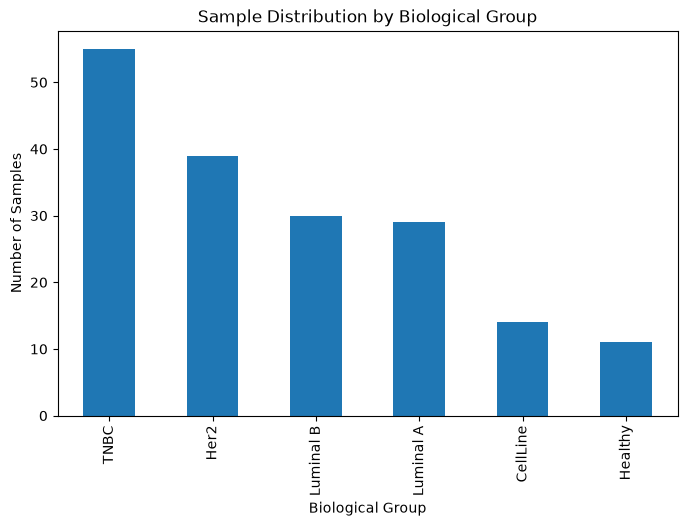

In [19]:
import matplotlib.pyplot as plt

sample_metadata["Group"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Biological Group")
plt.ylabel("Number of Samples")
plt.title("Sample Distribution by Biological Group")
plt.show()

## 2- Mapping Probe IDs to Gene Symbols

In [20]:
platform_id = "GPL570"

print(f"Platform: {platform_id}")

Platform: GPL570


In [21]:
import urllib.request

platform_url = (
    "https://ftp.ncbi.nlm.nih.gov/geo/platforms/"
    "GPLnnn/GPL570/annot/"
    "GPL570.annot.gz"
)

platform_file = "../data/raw/GPL570.annot.gz"

urllib.request.urlretrieve(
    platform_url,
    platform_file
)

print("Platform annotation downloaded.")

Platform annotation downloaded.


In [22]:
import gzip

with gzip.open(platform_file, "rt", encoding="latin1") as f:
    for _ in range(30):
        print(next(f).rstrip())

^Annotation
!Annotation_date = Aug 09 2016
!Annotation_platform = GPL570
!Annotation_platform_title = [HG-U133_Plus_2] Affymetrix Human Genome U133 Plus 2.0 Array
!Annotation_platform_organism = Homo sapiens
#ID = ID from Platform data table
#Gene title = Entrez Gene name
#Gene symbol = Entrez Gene symbol
#Gene ID = Entrez Gene identifier
#UniGene title = Entrez UniGene name
#UniGene symbol = Entrez UniGene symbol
#UniGene ID = Entrez UniGene identifier
#Nucleotide Title = Entrez Nucleotide title
#GI = GenBank identifier
#GenBank Accession = GenBank accession
#Platform_CLONEID = CLONE_ID from Platform data table
#Platform_ORF = ORF from Platform data table
#Platform_SPOTID = SPOT_ID from Platform data table
#Chromosome location = Entrez gene chromosome and location
#Chromosome annotation = Entrez gene chromosome annotation
#GO:Function = Gene Ontology Function term
#GO:Process = Gene Ontology Process term
#GO:Component = Gene Ontology Component term
#GO:Function ID = Gene Ontology Func

- Probe Annotation (Reading the Annotation File)

- Find the main Annotation table

In [29]:
annotation_file = "../data/raw/GPL570.annot.gz"
with gzip.open(annotation_file, "rt", encoding="latin1") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "!platform_table_begin" in line:
        print("Table starts at line:", i)
        print(lines[i])
        print(lines[i + 1])
        print(lines[i + 2])
        print(lines[i + 3])
        break

Table starts at line: 26
!platform_table_begin

ID	Gene title	Gene symbol	Gene ID	UniGene title	UniGene symbol	UniGene ID	Nucleotide Title	GI	GenBank Accession	Platform_CLONEID	Platform_ORF	Platform_SPOTID	Chromosome location	Chromosome annotation	GO:Function	GO:Process	GO:Component	GO:Function ID	GO:Process ID	GO:Component ID

1007_s_at	microRNA 4640///discoidin domain receptor tyrosine kinase 1	MIR4640///DDR1	100616237///780				Human receptor tyrosine kinase DDR gene, complete cds	1753221	U48705				6p21.3	Chromosome 6, NC_000006.12 (30890883..30890972)///Chromosome 6, NC_000006.12 (30880909..30900156)	ATP binding///collagen binding///collagen binding///metal ion binding///protein binding///protein tyrosine kinase collagen receptor activity///transmembrane receptor protein tyrosine kinase activity	branching involved in mammary gland duct morphogenesis///cell adhesion///collagen-activated tyrosine kinase receptor signaling pathway///collagen-activated tyrosine kinase receptor signaling

In [30]:
annotation = pd.read_csv(
    annotation_file,
    sep="\t",
    skiprows=27,
    dtype=str
)

In [32]:
annotation.head()

,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID
0,1007_s_at,microRNA 4640///discoidin domain receptor tyro...,MIR4640///DDR1,100616237///780,NaN,NaN,NaN,"Human receptor tyrosine kinase DDR gene, compl...",1753221,U48705,...,NaN,NaN,6p21.3,"Chromosome 6, NC_000006.12 (30890883..30890972...",ATP binding///collagen binding///collagen bind...,branching involved in mammary gland duct morph...,basolateral plasma membrane///extracellular ex...,GO:0005524///GO:0005518///GO:0005518///GO:0046...,GO:0060444///GO:0007155///GO:0038063///GO:0038...,GO:0016323///GO:0070062///GO:0005615///GO:0005...
1,1053_at,replication factor C subunit 2,RFC2,5982,NaN,NaN,NaN,"Human replication factor C, 40-kDa subunit (A1...",1590810,M87338,...,NaN,NaN,7q11.23,"Chromosome 7, NC_000007.14 (74231502..74254458...",ATP binding///contributes_to DNA clamp loader ...,"DNA damage response, detection of DNA damage//...",Ctf18 RFC-like complex///DNA replication facto...,GO:0005524///contributes_to GO:0003689///GO:00...,GO:0042769///GO:0006260///GO:0070987///GO:0042...,GO:0031390///GO:0005663///GO:0005654
2,117_at,heat shock protein family A (Hsp70) member 6,HSPA6,3310,NaN,NaN,NaN,Human heat-shock protein HSP70B' gene,35221,X51757,...,NaN,NaN,1q23,"Chromosome 1, NC_000001.11 (161524540..161526897)","ATP binding///ATPase activity, coupled///enzym...",NOT cellular heat acclimation///cellular respo...,colocalizes_with COP9 signalosome///blood micr...,GO:0005524///GO:0042623///GO:0019899///GO:0031...,NOT GO:0070370///GO:0034605///GO:0034605///GO:...,colocalizes_with GO:0008180///GO:0072562///GO:...
3,121_at,paired box 8,PAX8,7849,NaN,NaN,NaN,H.sapiens Pax8 mRNA,38425,X69699,...,NaN,NaN,2q13,"Chromosome 2, NC_000002.12 (113215997..1132789...",DNA binding///DNA binding///RNA polymerase II ...,anatomical structure morphogenesis///branching...,nucleoplasm///nucleoplasm///nucleus,GO:0003677///GO:0003677///GO:0000978///GO:0000...,GO:0009653///GO:0001658///GO:0071371///GO:0007...,GO:0005654///GO:0005654///GO:0005634
4,1255_g_at,guanylate cyclase activator 1A,GUCA1A,2978,NaN,NaN,NaN,Homo sapiens guanylate cyclase activating prot...,623404,L36861,...,NaN,NaN,6p21.1,"Chromosome 6, NC_000006.12 (42155377..42180083)",calcium ion binding///calcium sensitive guanyl...,cellular response to calcium ion///phototransd...,photoreceptor disc membrane///photoreceptor in...,GO:0005509///GO:0008048///GO:0030249,GO:0071277///GO:0007602///GO:0031284///GO:0022...,GO:0097381///GO:0001917///GO:0005886


- Only the columns we need

The entire Annotation has a lot of columns:

In [33]:
annotation_small = annotation[
    [
        "ID",
        "Gene symbol",
        "Gene ID"
    ]
].copy()

annotation_small.head()

,ID,Gene symbol,Gene ID
0,1007_s_at,MIR4640///DDR1,100616237///780
1,1053_at,RFC2,5982
2,117_at,HSPA6,3310
3,121_at,PAX8,7849
4,1255_g_at,GUCA1A,2978


In [34]:
annotation_small = annotation_small.rename(
    columns={
        "ID": "Probe_ID",
        "Gene symbol": "Gene_Symbol",
        "Gene ID": "Gene_ID"
    }
)

annotation_small.head()

,Probe_ID,Gene_Symbol,Gene_ID
0,1007_s_at,MIR4640///DDR1,100616237///780
1,1053_at,RFC2,5982
2,117_at,HSPA6,3310
3,121_at,PAX8,7849
4,1255_g_at,GUCA1A,2978


In [35]:
annotation_small.shape

(54676, 3)

In [36]:
df.index.name

'ID_REF'

In [37]:
df.index[:10]

Index(['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at',
       '1316_at', '1320_at', '1405_i_at', '1431_at'],
      dtype='str', name='ID_REF')

In [38]:
expression = df.reset_index()

expression.head()

C:\Users\paris\AppData\Local\Temp\ipykernel_7244\851382713.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  expression = df.reset_index()


,ID_REF,GSM1588970,GSM1588971,GSM1588972,GSM1588973,GSM1588974,GSM1588975,GSM1588976,GSM1588977,GSM1588978,...,GSM1589144,GSM1589145,GSM1589146,GSM1589147,GSM1589148,GSM1589149,GSM1589150,GSM1589151,GSM1589152,GSM1589153
0,1007_s_at,10.411779,10.488352,10.845107,10.702966,9.098584,9.829192,9.470653,9.664682,9.684121,...,9.804565,9.969140,11.184470,6.374995,8.928622,9.784214,9.563211,8.517468,8.451605,8.843594
1,1053_at,6.591003,6.746441,7.785105,7.680055,8.492950,8.043909,8.363112,8.740721,8.703165,...,6.544417,5.457921,9.024600,9.044131,4.979578,9.551200,5.956611,5.626144,8.426716,9.078589
2,117_at,5.903459,5.964176,7.073847,6.238866,7.898332,6.251101,5.954255,7.188710,6.861743,...,3.370990,3.143524,3.144014,3.759428,3.405318,4.397315,4.524447,4.930555,3.260828,3.845806
3,121_at,2.708618,2.289952,2.391005,2.803893,2.794781,2.782041,2.806578,3.108409,3.836726,...,2.708220,2.701309,2.596828,5.574557,2.860321,2.871901,2.733621,2.737100,2.628306,5.842461
4,1255_g_at,2.058521,2.055400,2.055344,2.080104,2.052719,2.065556,2.057589,2.069383,2.047526,...,2.080661,2.069928,2.102840,2.116986,2.128656,2.105839,2.067705,2.080564,2.099971,2.076347


In [39]:
df.head()

,GSM1588970,GSM1588971,GSM1588972,GSM1588973,GSM1588974,GSM1588975,GSM1588976,GSM1588977,GSM1588978,GSM1588979,...,GSM1589144,GSM1589145,GSM1589146,GSM1589147,GSM1589148,GSM1589149,GSM1589150,GSM1589151,GSM1589152,GSM1589153
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,10.411779,10.488352,10.845107,10.702966,9.098584,9.829192,9.470653,9.664682,9.684121,9.763926,...,9.804565,9.969140,11.184470,6.374995,8.928622,9.784214,9.563211,8.517468,8.451605,8.843594
1053_at,6.591003,6.746441,7.785105,7.680055,8.492950,8.043909,8.363112,8.740721,8.703165,9.211186,...,6.544417,5.457921,9.024600,9.044131,4.979578,9.551200,5.956611,5.626144,8.426716,9.078589
117_at,5.903459,5.964176,7.073847,6.238866,7.898332,6.251101,5.954255,7.188710,6.861743,6.205198,...,3.370990,3.143524,3.144014,3.759428,3.405318,4.397315,4.524447,4.930555,3.260828,3.845806
121_at,2.708618,2.289952,2.391005,2.803893,2.794781,2.782041,2.806578,3.108409,3.836726,3.923927,...,2.708220,2.701309,2.596828,5.574557,2.860321,2.871901,2.733621,2.737100,2.628306,5.842461
1255_g_at,2.058521,2.055400,2.055344,2.080104,2.052719,2.065556,2.057589,2.069383,2.047526,2.062470,...,2.080661,2.069928,2.102840,2.116986,2.128656,2.105839,2.067705,2.080564,2.099971,2.076347


In [40]:
expression.head()

,ID_REF,GSM1588970,GSM1588971,GSM1588972,GSM1588973,GSM1588974,GSM1588975,GSM1588976,GSM1588977,GSM1588978,...,GSM1589144,GSM1589145,GSM1589146,GSM1589147,GSM1589148,GSM1589149,GSM1589150,GSM1589151,GSM1589152,GSM1589153
0,1007_s_at,10.411779,10.488352,10.845107,10.702966,9.098584,9.829192,9.470653,9.664682,9.684121,...,9.804565,9.969140,11.184470,6.374995,8.928622,9.784214,9.563211,8.517468,8.451605,8.843594
1,1053_at,6.591003,6.746441,7.785105,7.680055,8.492950,8.043909,8.363112,8.740721,8.703165,...,6.544417,5.457921,9.024600,9.044131,4.979578,9.551200,5.956611,5.626144,8.426716,9.078589
2,117_at,5.903459,5.964176,7.073847,6.238866,7.898332,6.251101,5.954255,7.188710,6.861743,...,3.370990,3.143524,3.144014,3.759428,3.405318,4.397315,4.524447,4.930555,3.260828,3.845806
3,121_at,2.708618,2.289952,2.391005,2.803893,2.794781,2.782041,2.806578,3.108409,3.836726,...,2.708220,2.701309,2.596828,5.574557,2.860321,2.871901,2.733621,2.737100,2.628306,5.842461
4,1255_g_at,2.058521,2.055400,2.055344,2.080104,2.052719,2.065556,2.057589,2.069383,2.047526,...,2.080661,2.069928,2.102840,2.116986,2.128656,2.105839,2.067705,2.080564,2.099971,2.076347


- Merge

In [41]:
expression_annotated = expression.merge(
    annotation_small,
    left_on="ID_REF",
    right_on="Probe_ID",
    how="left"
)

In [42]:
expression_annotated.head()

,ID_REF,GSM1588970,GSM1588971,GSM1588972,GSM1588973,GSM1588974,GSM1588975,GSM1588976,GSM1588977,GSM1588978,...,GSM1589147,GSM1589148,GSM1589149,GSM1589150,GSM1589151,GSM1589152,GSM1589153,Probe_ID,Gene_Symbol,Gene_ID
0,1007_s_at,10.411779,10.488352,10.845107,10.702966,9.098584,9.829192,9.470653,9.664682,9.684121,...,6.374995,8.928622,9.784214,9.563211,8.517468,8.451605,8.843594,1007_s_at,MIR4640///DDR1,100616237///780
1,1053_at,6.591003,6.746441,7.785105,7.680055,8.492950,8.043909,8.363112,8.740721,8.703165,...,9.044131,4.979578,9.551200,5.956611,5.626144,8.426716,9.078589,1053_at,RFC2,5982
2,117_at,5.903459,5.964176,7.073847,6.238866,7.898332,6.251101,5.954255,7.188710,6.861743,...,3.759428,3.405318,4.397315,4.524447,4.930555,3.260828,3.845806,117_at,HSPA6,3310
3,121_at,2.708618,2.289952,2.391005,2.803893,2.794781,2.782041,2.806578,3.108409,3.836726,...,5.574557,2.860321,2.871901,2.733621,2.737100,2.628306,5.842461,121_at,PAX8,7849
4,1255_g_at,2.058521,2.055400,2.055344,2.080104,2.052719,2.065556,2.057589,2.069383,2.047526,...,2.116986,2.128656,2.105839,2.067705,2.080564,2.099971,2.076347,1255_g_at,GUCA1A,2978


- Mapping Success Review

What percentage of probes are mapped to the Gene Symbol?

In [43]:
mapped = expression_annotated["Gene_Symbol"].notna().sum()
total = len(expression_annotated)

print(f"Mapped probes: {mapped:,}")
print(f"Total probes: {total:,}")
print(f"Mapping rate: {mapped / total:.2%}")

Mapped probes: 45,116
Total probes: 54,673
Mapping rate: 82.52%


This shows us if we have genes that have multiple probes.

In [44]:
annotation_small["Gene_Symbol"].value_counts().head(10)

Gene_Symbol
YME1L1                                 20
HFE                                    15
TCF3                                   14
CFLAR                                  14
CSNK1A1                                13
CD44                                   13
DNAH1                                  13
ARHGEF12                               13
LOC101928269///LOC100506403///RUNX1    13
MAGI1                                  12
Name: count, dtype: int64

## Step 3 - Gene Expression Dataset Creation

Now we have two DataFrames:

- Expression
54,673 probes × 178 samples
- Annotation
54,676 probes × 3

And we have merged them.

- But for Visualization, we don't want to examine all 54,000 Probes.
We want to create a small but realistic and biologically meaningful dataset.

such as: 
- TP53
BRCA1
BRCA2
ESR1
ERBB2
MKI67
GATA3
PTEN
EGFR
AKT1

1. Breast cancer subtype markers

ESR1
ERBB2
GATA3

2. Tumor suppressors / DNA repair

TP53
BRCA1
BRCA2
PTEN

3. Signaling

EGFR
AKT1

4. Cell proliferation

MKI67

#### Can gene expression patterns help distinguish breast cancer subtypes and other biological sample groups?

```text
54,673 Probes
       ↓
Annotation
       ↓
Select 5 Genes
       ↓
TP53 / BRCA1 / ESR1 / ERBB2 / MKI67
       ↓
Multiple Probes per Gene
       ↓
Median Aggregation
       ↓
Gene-level Expression
       ↓
Add Group / Subtype Information
       ↓
       ┌─────────────────────────┐
       │ Luminal A               │
       │ Luminal B               │
       │ HER2                    │
       │ TNBC                    │
       │ Healthy                 │
       │ CellLine                │
       └─────────────────────────┘
       ↓
Heatmap / Boxplot
       ↓
Analyze Differences in Gene Expression Patterns
```

In [45]:
selected_genes = [
    "TP53",
    "BRCA1",
    "ESR1",
    "ERBB2",
    "MKI67"
]

check if these genes are in the annotation.

In [48]:
for gene in selected_genes:
    symbols = (
        annotation_small["Gene_Symbol"]
        .fillna("")
        .str.split("///")
        .explode()
    )

    symbols = symbols.astype(str).str.strip()

    count = symbols.eq(gene).sum()

    print(f"{gene}: {count} probe(s)")

TP53: 2 probe(s)
BRCA1: 2 probe(s)
ESR1: 9 probe(s)
ERBB2: 3 probe(s)
MKI67: 4 probe(s)


- Extraction of probes related to selected genes

In [49]:
from pandas.core.frame import DataFrame


gene_annotation: DataFrame = annotation_small.copy()

gene_annotation["Gene_Symbol_Clean"] = (
    gene_annotation["Gene_Symbol"]
    .fillna("")
    .str.split("///")
)

gene_annotation = gene_annotation.explode(
    "Gene_Symbol_Clean"
)

gene_annotation["Gene_Symbol_Clean"] = (
    gene_annotation["Gene_Symbol_Clean"]
    .str.strip()
)
gene_annotation.head(10)

,Probe_ID,Gene_Symbol,Gene_ID,Gene_Symbol_Clean
0,1007_s_at,MIR4640///DDR1,100616237///780,MIR4640
0,1007_s_at,MIR4640///DDR1,100616237///780,DDR1
1,1053_at,RFC2,5982,RFC2
2,117_at,HSPA6,3310,HSPA6
3,121_at,PAX8,7849,PAX8
4,1255_g_at,GUCA1A,2978,GUCA1A
5,1294_at,MIR5193///UBA7,100847079///7318,MIR5193
5,1294_at,MIR5193///UBA7,100847079///7318,UBA7
6,1316_at,THRA,7067,THRA
7,1320_at,PTPN21,11099,PTPN21


In [50]:
selected_annotation = gene_annotation[
    gene_annotation["Gene_Symbol_Clean"].isin(selected_genes)
].copy()

selected_annotation[
    ["Probe_ID", "Gene_Symbol_Clean", "Gene_ID"]
].head(20)

,Probe_ID,Gene_Symbol_Clean,Gene_ID
11194,201746_at,TP53,7157
13978,204531_s_at,BRCA1,672
14672,205225_at,ESR1,2099
20297,210930_s_at,ERBB2,2064
20591,211233_x_at,ESR1,2099
20592,211234_x_at,ESR1,2099
20593,211235_s_at,ESR1,2099
20643,211300_s_at,TP53,7157
20952,211627_x_at,ESR1,2099
21165,211851_x_at,BRCA1,672


connect the Expression to this Annotation

In [51]:
selected_expression = expression_annotated[
    expression_annotated["Probe_ID"].isin(
        selected_annotation["Probe_ID"]
    )
].copy()

In [52]:
selected_expression[
    ["Probe_ID", "Gene_Symbol", "Gene_ID"]
].head()

,Probe_ID,Gene_Symbol,Gene_ID
11194,201746_at,TP53,7157
13978,204531_s_at,BRCA1,672
14672,205225_at,ESR1,2099
20297,210930_s_at,ERBB2,2064
20591,211233_x_at,ESR1,2099


In [54]:
selected_genes = [
    "TP53",
    "BRCA1",
    "ESR1",
    "ERBB2",
    "MKI67"
]

#### From Probe-Level to Gene-Level Expression
- A single gene may be represented by multiple probes on an Affymetrix microarray.

- For this educational analysis, we aggregate multiple probes belonging to the same gene using the median expression value.

Note: This is a simplified educational strategy. Probe summarization in rigorous microarray analysis may involve more sophisticated methods.

- Selection of probes related to genes:

In [73]:
selected_expression[
    ["Probe_ID", "Gene_Symbol", "Gene_ID"]
].head(20)

,Probe_ID,Gene_Symbol,Gene_ID
0,201746_at,TP53,7157
1,204531_s_at,BRCA1,672
2,205225_at,ESR1,2099
3,210930_s_at,ERBB2,2064
4,211233_x_at,ESR1,2099
5,211234_x_at,ESR1,2099
6,211235_s_at,ESR1,2099
7,211300_s_at,TP53,7157
8,211627_x_at,ESR1,2099
9,211851_x_at,BRCA1,672


- Clean the Gene Symbol:

Because some annotations like: MIR4640///DDR1
- have, it is better to use the same selected_annotation for our selected genes.

If selected_expression does not yet have the cleaned column:

In [56]:
selected_expression = selected_expression.merge(
    selected_annotation[
        ["Probe_ID", "Gene_Symbol_Clean"]
    ],
    on="Probe_ID",
    how="left"
)

In [57]:
selected_expression[
    ["Probe_ID", "Gene_Symbol_Clean"]
].head()

,Probe_ID,Gene_Symbol_Clean
0,201746_at,TP53
1,204531_s_at,BRCA1
2,205225_at,ESR1
3,210930_s_at,ERBB2
4,211233_x_at,ESR1


- Because our metadata file is CSV and the Sample IDs are stored with quotes:

In [59]:
print(sample_metadata["Sample_ID"].head().tolist())
print(selected_expression.columns[:10].tolist())

['"GSM1588970"', '"GSM1588971"', '"GSM1588972"', '"GSM1588973"', '"GSM1588974"']
['ID_REF', 'GSM1588970', 'GSM1588971', 'GSM1588972', 'GSM1588973', 'GSM1588974', 'GSM1588975', 'GSM1588976', 'GSM1588977', 'GSM1588978']


- So we remove the extra "s" from Sample_ID:

In [60]:
sample_metadata["Sample_ID"] = (
    sample_metadata["Sample_ID"]
    .astype(str)
    .str.strip()
    .str.strip('"')
)

In [61]:
print(sample_metadata["Sample_ID"].head().tolist())
print(selected_expression.columns[:10].tolist())

['GSM1588970', 'GSM1588971', 'GSM1588972', 'GSM1588973', 'GSM1588974']
['ID_REF', 'GSM1588970', 'GSM1588971', 'GSM1588972', 'GSM1588973', 'GSM1588974', 'GSM1588975', 'GSM1588976', 'GSM1588977', 'GSM1588978']


- Separate only the Expression columns:

In [83]:
sample_columns = sample_metadata["Sample_ID"].tolist()

expression_values = selected_expression[
    ["Probe_ID", "Gene_Symbol_Clean"] + sample_columns
].copy()


expression_values

,Probe_ID,Gene_Symbol_Clean,GSM1588970,GSM1588971,GSM1588972,GSM1588973,GSM1588974,GSM1588975,GSM1588976,GSM1588977,...,GSM1589144,GSM1589145,GSM1589146,GSM1589147,GSM1589148,GSM1589149,GSM1589150,GSM1589151,GSM1589152,GSM1589153
0,201746_at,TP53,5.253057,5.155959,7.010976,7.071730,7.928478,5.149311,8.553121,8.168685,...,7.651183,8.092781,9.611066,10.544788,7.340589,9.058232,6.994542,6.482911,2.939857,8.826440
1,204531_s_at,BRCA1,7.148729,7.289124,6.686296,6.832760,7.654996,7.134584,6.988955,5.195883,...,6.641663,6.615750,8.995893,8.569170,7.373814,8.946863,6.261148,6.085314,8.125073,8.899216
2,205225_at,ESR1,2.252392,2.811044,4.651572,3.398460,1.977895,2.819809,3.430675,1.426018,...,9.016971,7.401172,2.247597,1.605436,8.082197,2.580061,10.508748,7.101032,1.585375,1.670726
3,210930_s_at,ERBB2,2.927462,2.593274,8.559689,7.652147,2.600768,2.641142,1.681086,2.624411,...,2.812965,2.794454,2.720780,2.623096,2.475363,2.502062,2.355508,2.363433,2.409836,2.279290
4,211233_x_at,ESR1,1.877097,1.875207,1.878432,1.893947,1.870550,1.885172,1.877801,1.879456,...,1.885285,1.873811,1.889447,1.905835,1.897194,1.898548,1.880117,1.892510,1.912659,1.897373
5,211234_x_at,ESR1,2.045121,2.035956,2.039816,2.060222,2.026561,2.049235,2.022583,2.033873,...,2.127220,2.035929,2.061342,2.067537,2.068607,2.074882,2.048138,2.074375,2.085924,2.059429
6,211235_s_at,ESR1,2.360525,2.362212,2.346526,2.387663,2.354116,2.374093,2.363192,2.363103,...,2.919823,2.657695,2.423261,2.487186,2.415859,2.405442,2.370409,2.378112,2.406909,2.448892
7,211300_s_at,TP53,3.793226,3.833013,4.062867,3.879358,5.563041,3.841702,8.449206,7.963968,...,3.727579,3.969247,9.167222,9.260624,3.737138,8.785585,4.342612,3.581821,4.138260,7.516497
8,211627_x_at,ESR1,3.346371,3.352436,3.476414,3.541243,3.326488,3.349816,3.441746,3.433100,...,3.980844,3.974173,3.767754,3.938310,4.747933,3.780751,4.202775,4.152898,3.810929,3.643960
9,211851_x_at,BRCA1,3.143311,3.082121,3.031618,3.098017,3.543610,3.494747,3.063502,3.017736,...,2.989991,2.973172,3.446523,3.326524,3.112300,4.060528,3.177013,3.178699,3.272779,4.566243


- After probe annotation, we aggregate multiple probes belonging to the same gene.

```text
Probe-level data

TP53 probe 1 ─┐
TP53 probe 2 ─┼──→ Median ──→ TP53
TP53 probe 3 ─┘
```

In [64]:
gene_expression = (
    expression_values
    .groupby("Gene_Symbol_Clean")[sample_columns]
    .median()
)

In [66]:
print(gene_expression.shape)

(5, 178)


The resulting matrix contains: 5 genes × 178 samples

This compact dataset will be used for visualization.

In [68]:
gene_expression.describe()

,GSM1588970,GSM1588971,GSM1588972,GSM1588973,GSM1588974,GSM1588975,GSM1588976,GSM1588977,GSM1588978,GSM1588979,...,GSM1589144,GSM1589145,GSM1589146,GSM1589147,GSM1589148,GSM1589149,GSM1589150,GSM1589151,GSM1589152,GSM1589153
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,4.609852,4.551296,5.354573,5.039480,4.965056,4.502766,5.116719,5.008802,4.813158,4.909563,...,3.818530,3.785716,5.755886,5.364674,3.711800,5.441156,3.595354,3.444325,4.103029,5.659159
std,2.294915,2.345502,2.215347,1.886872,2.417917,2.181261,2.694676,2.819157,2.799926,3.072273,...,1.401026,1.568148,3.180381,3.084818,1.547040,2.878702,1.511189,1.289103,1.885798,3.150262
min,2.295359,2.342138,2.343721,2.369953,2.273175,2.352816,2.346591,2.302147,2.298334,2.348114,...,2.334498,2.311731,2.286049,2.333255,2.415859,2.405442,2.355508,2.362250,2.399644,2.279290
25%,2.927462,2.593274,4.858957,4.734367,2.600768,2.641142,2.644415,2.624411,2.640630,2.596384,...,2.812965,2.794454,2.720780,2.623096,2.475363,2.502062,2.370409,2.363433,2.409836,2.332209
50%,4.523142,4.494486,5.473577,4.965389,5.599303,4.495507,5.026228,4.106809,3.433590,3.449265,...,3.439980,2.996922,6.221208,5.947847,2.885858,6.503696,2.863197,2.831567,3.539059,6.732730
75%,5.146020,5.185623,5.536922,5.475544,6.745760,5.314665,7.065198,7.944316,7.786850,6.726929,...,4.815827,4.794461,8.162247,6.016468,5.243057,6.872672,4.719080,4.632007,5.698926,8.171468
max,8.157279,8.140961,8.559689,7.652147,7.606273,7.709701,8.501164,8.066326,7.906386,9.427122,...,5.689381,6.031014,9.389144,9.902706,5.538863,8.921908,5.668577,5.032366,6.467678,8.780097


#### Melt() : Wide DF --> Long DF

In [85]:
gene_expression.head()

,GSM1588970,GSM1588971,GSM1588972,GSM1588973,GSM1588974,GSM1588975,GSM1588976,GSM1588977,GSM1588978,GSM1588979,...,GSM1589144,GSM1589145,GSM1589146,GSM1589147,GSM1589148,GSM1589149,GSM1589150,GSM1589151,GSM1589152,GSM1589153
Gene_Symbol_Clean,,,,,,,,,,,,,,,,,,,,,
BRCA1,5.146020,5.185623,4.858957,4.965389,5.599303,5.314665,5.026228,4.106809,3.433590,3.449265,...,4.815827,4.794461,6.221208,5.947847,5.243057,6.503696,4.719080,4.632007,5.698926,6.732730
ERBB2,2.927462,2.593274,8.559689,7.652147,2.600768,2.641142,2.644415,2.624411,2.640630,2.596384,...,2.812965,2.794454,2.720780,2.623096,2.475363,2.502062,2.355508,2.363433,2.409836,2.279290
ESR1,2.295359,2.342138,2.343721,2.369953,2.273175,2.352816,2.346591,2.302147,2.298334,2.348114,...,2.334498,2.311731,2.286049,2.333255,2.415859,2.405442,2.370409,2.362250,2.399644,2.332209
MKI67,8.157279,8.140961,5.473577,4.734367,7.606273,7.709701,7.065198,7.944316,7.906386,9.427122,...,3.439980,2.996922,8.162247,6.016468,2.885858,6.872672,2.863197,2.831567,6.467678,8.780097
TP53,4.523142,4.494486,5.536922,5.475544,6.745760,4.495507,8.501164,8.066326,7.786850,6.726929,...,5.689381,6.031014,9.389144,9.902706,5.538863,8.921908,5.668577,5.032366,3.539059,8.171468


In [84]:
sample_metadata

,Sample_ID,Sample_Title,Group
0,GSM1588970,"""TNBC, TUM001_repA""",TNBC
1,GSM1588971,"""TNBC, TUM001_repB""",TNBC
2,GSM1588972,"""Her2, TUM002_repA""",Her2
3,GSM1588973,"""Her2, TUM002_repB""",Her2
4,GSM1588974,"""TNBC, TUM003""",TNBC
...,...,...,...
173,GSM1589149,"""CellLine, HCC70""",CellLine
174,GSM1589150,"""Healthy, H14""",Healthy
175,GSM1589151,"""Healthy, H5""",Healthy
176,GSM1589152,"""CellLine, MDA-MB-157""",CellLine


In [86]:
gene_expression_long = (
    gene_expression
    .reset_index()
    .melt(
        id_vars="Gene_Symbol_Clean",
        var_name="Sample_ID",
        value_name="Expression"
    )
)

In [87]:
gene_expression_long

,Gene_Symbol_Clean,Sample_ID,Expression
0,BRCA1,GSM1588970,5.146020
1,ERBB2,GSM1588970,2.927462
2,ESR1,GSM1588970,2.295359
3,MKI67,GSM1588970,8.157279
4,TP53,GSM1588970,4.523142
...,...,...,...
885,BRCA1,GSM1589153,6.732730
886,ERBB2,GSM1589153,2.279290
887,ESR1,GSM1589153,2.332209
888,MKI67,GSM1589153,8.780097


- Now it is ready for Merge with Metadata DF


In [88]:
analysis_df = gene_expression_long.merge(
    sample_metadata[
        ["Sample_ID", "Sample_Title", "Group"]
    ],
    on="Sample_ID",
    how="left"
)

In [91]:
analysis_df.shape

(890, 5)

In [90]:
analysis_df.head(10)

,Gene_Symbol_Clean,Sample_ID,Expression,Sample_Title,Group
0,BRCA1,GSM1588970,5.146020,"""TNBC, TUM001_repA""",TNBC
1,ERBB2,GSM1588970,2.927462,"""TNBC, TUM001_repA""",TNBC
2,ESR1,GSM1588970,2.295359,"""TNBC, TUM001_repA""",TNBC
3,MKI67,GSM1588970,8.157279,"""TNBC, TUM001_repA""",TNBC
4,TP53,GSM1588970,4.523142,"""TNBC, TUM001_repA""",TNBC
5,BRCA1,GSM1588971,5.185623,"""TNBC, TUM001_repB""",TNBC
6,ERBB2,GSM1588971,2.593274,"""TNBC, TUM001_repB""",TNBC
7,ESR1,GSM1588971,2.342138,"""TNBC, TUM001_repB""",TNBC
8,MKI67,GSM1588971,8.140961,"""TNBC, TUM001_repB""",TNBC
9,TP53,GSM1588971,4.494486,"""TNBC, TUM001_repB""",TNBC


This is our visualization-ready dataset.

#### Quality Check Before Visualization!

How many Missing (NaN) values ​​do we have in each column?

In [92]:
analysis_df.isna().sum()

Gene_Symbol_Clean    0
Sample_ID            0
Expression           0
Sample_Title         0
Group                0
dtype: int64

Count the number of records in each group.

In [93]:
analysis_df["Group"].value_counts()

Group
TNBC         275
Her2         195
Luminal B    150
Luminal A    145
CellLine      70
Healthy       55
Name: count, dtype: int64

Look at how many rows we have in the DataFrame for each Gene.

In [94]:
analysis_df["Gene_Symbol_Clean"].value_counts()

Gene_Symbol_Clean
BRCA1    178
ERBB2    178
ESR1     178
MKI67    178
TP53     178
Name: count, dtype: int64

For each gene, summarize the expression distribution.

In [97]:
analysis_df.groupby("Gene_Symbol_Clean")["Expression"].describe()

,count,mean,std,min,25%,50%,75%,max
Gene_Symbol_Clean,,,,,,,,
BRCA1,178.0,5.113375,0.763406,3.433590,4.721579,4.968913,5.457882,8.533514
ERBB2,178.0,4.749509,2.749436,2.255597,2.635647,2.943139,7.420570,11.555494
ESR1,178.0,2.467395,0.382160,2.235050,2.311106,2.347352,2.384924,4.800005
MKI67,178.0,5.931469,1.821067,2.600847,4.419425,6.276707,7.387923,10.087925
TP53,178.0,6.028713,1.359277,3.170059,5.226057,5.934860,6.941849,9.902706


We do not perform additional normalization because the GSE65194 expression data have already been normalized using GC-RMA as part of the original study preprocessing.

- Save preprocessed data for Visualization:

In [98]:
output_file = "../data/processed/breast_cancer_gene_expression.csv"

analysis_df.to_csv(
    output_file,
    index=False
)

print(f"Saved to: {output_file}")

Saved to: ../data/processed/breast_cancer_gene_expression.csv
